<a href="https://colab.research.google.com/github/kaushalkalas-awesome/DKTE-TY-DL/blob/main/DL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, initializers, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [ ]:
# --- Step 1: Load the Dataset ---
# MNIST is a dataset of 70,000 handwritten digits (0-9).
# The data is already split into a training set (60,000 images) and a testing set (10,000 images).
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# --- Step 2: Normalize the Image Data ---
# The pixel values in the images range from 0 (black) to 255 (white).
# Neural networks work best with small input values, so we scale the pixels to be between 0 and 1.
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# --- Step 3: Flatten the Images ---
# Our model will use "Dense" layers, which expect a flat list of numbers as input, not a 2D image.
# We reshape each 28x28 pixel image into a single long array of 784 pixels (28 * 28 = 784).
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

# --- Step 4: Convert Labels to "One-Hot" Format ---
# The labels are numbers from 0 to 9 (e.g., the image of a '7' has the label 7).
# We convert these numbers into a special format called "one-hot encoding".
# Example: The number 7 becomes [0,0,0,0,0,0,0,1,0,0].
# This format is needed for the loss function we will use to train the model.
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# --- Step 5: Verify the Data Shape ---
# Let's print the shapes to confirm our data is processed correctly.
print("Training data shape:", x_train.shape)      # Expected: (60000, 784)
print("Training labels shape:", y_train.shape)    # Expected: (60000, 10)
print("Testing data shape:", x_test.shape)        # Expected: (10000, 784)
print("Testing labels shape:", y_test.shape)      # Expected: (10000, 10)

Training data shape: (60000, 784)
Training labels shape: (60000, 10)
Testing data shape: (10000, 784)
Testing labels shape: (10000, 10)


In [ ]:
# epochs: How many times the model will see the entire training dataset.
# batch_size: How many images to process before updating the model's weights.
epochs = 15
batch_size = 128

# A Sequential model is a simple stack of layers, one after the other.
model = models.Sequential()

# Layer 1: Input Layer
# - Dense: A fully connected layer. Every neuron is connected to every neuron in the next layer.
# - 128: The number of neurons in this hidden layer.
# - activation='relu': A common activation function that helps the model learn complex patterns.
# - input_shape=(784,): We must tell the first layer the shape of our input data (flattened 28x28 images).
# - kernel_initializer: Sets the initial weights for this layer using the specified recipe.
model.add(layers.Dense(128, activation='relu', input_shape=(784,), kernel_initializer=initializers.he_normal()))

# Layer 2: Second Hidden Layer
# - 64: The number of neurons in this layer.
# - We don't need input_shape here; Keras automatically figures it out from the previous layer.
model.add(layers.Dense(64, activation='relu', kernel_initializer=initializers.he_normal()))

# Layer 3: Output Layer
# - 10: We need 10 neurons because there are 10 possible digits (0-9).
# - activation='softmax': This function turns the outputs into probabilities,
#   making it easy to pick the digit with the highest score.
model.add(layers.Dense(10, activation='softmax', kernel_initializer=initializers.he_normal()))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nModel Summary:")
print(model.summary())

history = model.fit(
  x_train, y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_data=(x_test, y_test),
  verbose=1  # Set to 0 to hide the progress bar
)


Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8392 - loss: 0.5629 - val_accuracy: 0.9520 - val_loss: 0.1679
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9557 - loss: 0.1534 - val_accuracy: 0.9675 - val_loss: 0.1075
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9721 - loss: 0.0956 - val_accuracy: 0.9678 - val_loss: 0.1007
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9783 - loss: 0.0718 - val_accuracy: 0.9753 - val_loss: 0.0820
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9837 - loss: 0.0551 - val_accuracy: 0.9712 - val_loss: 0.0930
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9871 - loss: 0.0438 - val_accuracy: 0.9724 - val_loss: 0.0904
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9897 - loss: 0.0334 - val_accuracy: 0.9754 - val_loss: 0.0816
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9908 - loss: 0.0304 - val_accurac

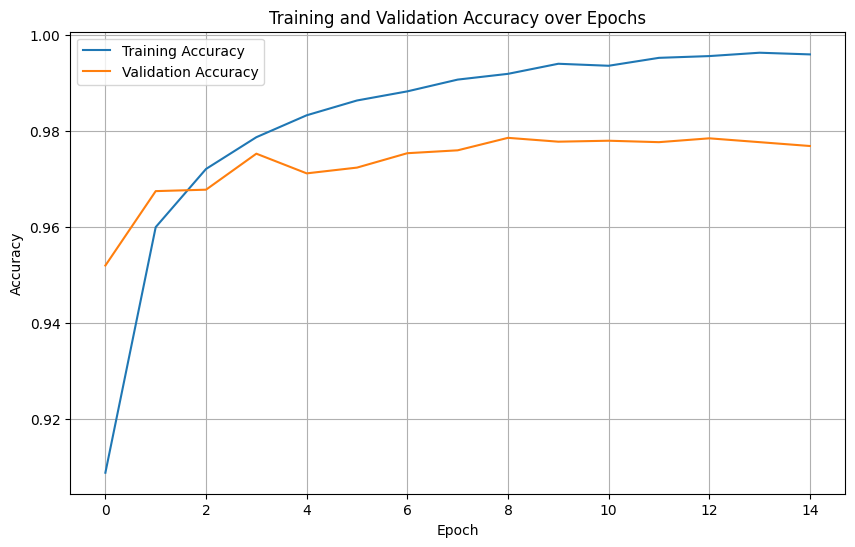

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

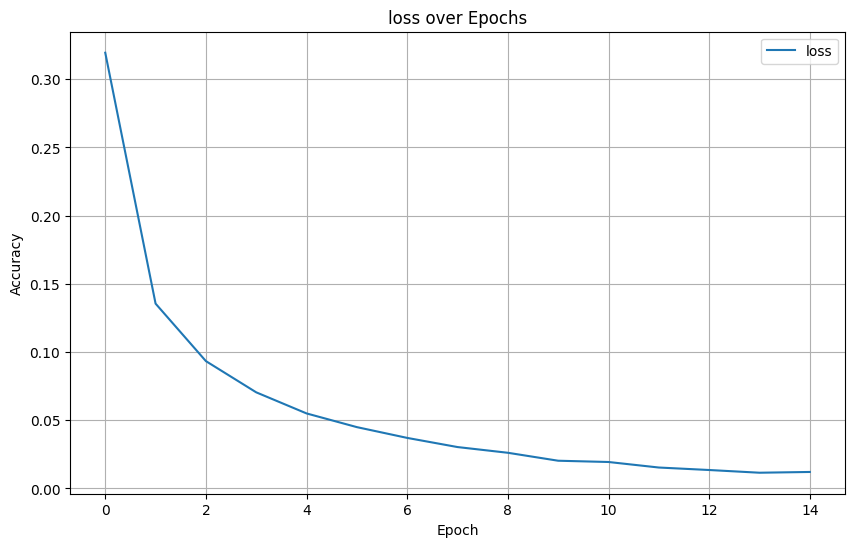

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='loss')
plt.title('loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epochs: How many times the model will see the entire training dataset.
# batch_size: How many images to process before updating the model's weights.
epochs = 15
batch_size = 128

# A Sequential model is a simple stack of layers, one after the other.
model = models.Sequential()

# Layer 1: Input Layer with Batch Normalization
# Apply Dense layer, then BatchNormalization, then Activation.
model.add(layers.Dense(128, kernel_initializer=initializers.he_normal(), input_shape=(784,)))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))

# Layer 2: Second Hidden Layer with Batch Normalization
model.add(layers.Dense(64, kernel_initializer=initializers.he_normal()))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))

# Layer 3: Output Layer
model.add(layers.Dense(10, activation='softmax', kernel_initializer=initializers.he_normal()))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nModel Summary:")
print(model.summary())

batch_history = model.fit(
  x_train, y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_data=(x_test, y_test),
  verbose=1  # Set to 0 to hide the progress bar
)


Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

None
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8432 - loss: 0.5650 - val_accuracy: 0.9640 - val_loss: 0.1320
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9659 - loss: 0.1158 - val_accuracy: 0.9713 - val_loss: 0.0956
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9803 - loss: 0.0695 - val_accuracy: 0.9760 - val_loss: 0.0731
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9860 - loss: 0.0475 - val_accuracy: 0.9737 - val_loss: 0.0759
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9898 - loss: 0.0369 - val_accuracy: 0.9756 - val_loss: 0.0747
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9923 - loss: 0.0265 - val_accuracy: 0.9742 - val_loss: 0.0852
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9924 - loss: 0.0252 - val_accuracy: 0.9756 - val_loss: 0.0753
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9951 - loss: 0.0184 - val_accurac

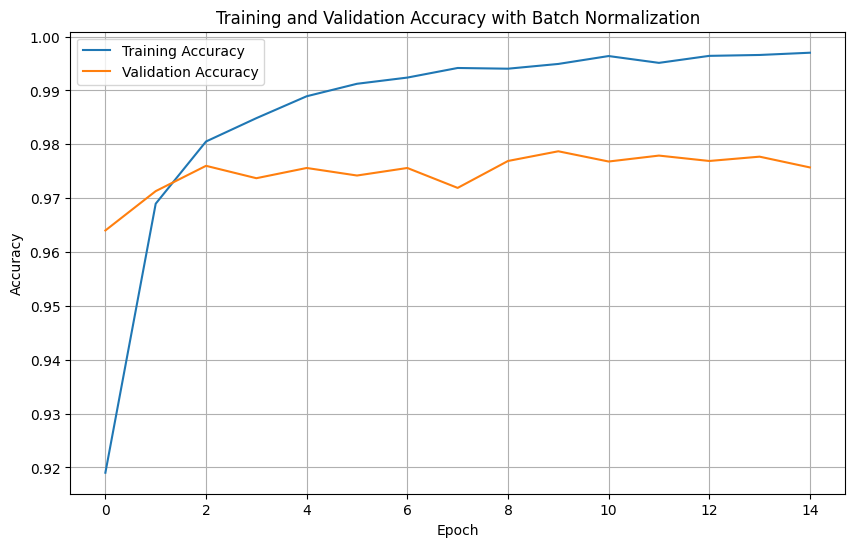

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(batch_history.history['accuracy'], label='Training Accuracy')
plt.plot(batch_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Batch Normalization')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

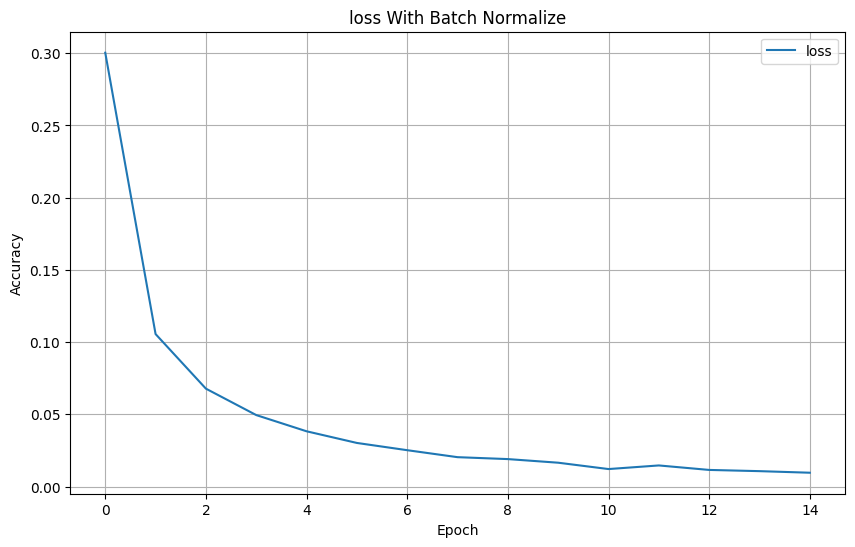

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(batch_history.history['loss'], label='loss')
plt.title('loss With Batch Normalize')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epochs: How many times the model will see the entire training dataset.
# batch_size: How many images to process before updating the model's weights.
epochs = 15
batch_size = 128

# A Sequential model is a simple stack of layers, one after the other.
model = models.Sequential()

# Layer 1: Input Layer with L2 regularization
model.add(layers.Dense(128, activation='relu', kernel_initializer=initializers.he_normal(),
                       kernel_regularizer=keras.regularizers.l2(0.001), input_shape=(784,)))

# Layer 2: Second Hidden Layer with L2 regularization
model.add(layers.Dense(64, activation='relu', kernel_initializer=initializers.he_normal(),
                      kernel_regularizer=keras.regularizers.l2(0.001)))

# Layer 3: Output Layer
model.add(layers.Dense(10, activation='softmax', kernel_initializer=initializers.he_normal()))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nModel Summary:")
print(model.summary())

l2_history = model.fit(
  x_train, y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_data=(x_test, y_test),
  verbose=1  # Set to 0 to hide the progress bar
)


Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8201 - loss: 0.8854 - val_accuracy: 0.9503 - val_loss: 0.3488
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9538 - loss: 0.3315 - val_accuracy: 0.9602 - val_loss: 0.2846
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9649 - loss: 0.2606 - val_accuracy: 0.9667 - val_loss: 0.2389
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9695 - loss: 0.2295 - val_accuracy: 0.9697 - val_loss: 0.2139
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9751 - loss: 0.2010 - val_accuracy: 0.9736 - val_loss: 0.1946
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9756 - loss: 0.1824 - val_accuracy: 0.9726 - val_loss: 0.1894
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9786 - loss: 0.1738 - val_accuracy: 0.9735 - val_loss: 0.1793
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9795 - loss: 0.1652 - val_accurac

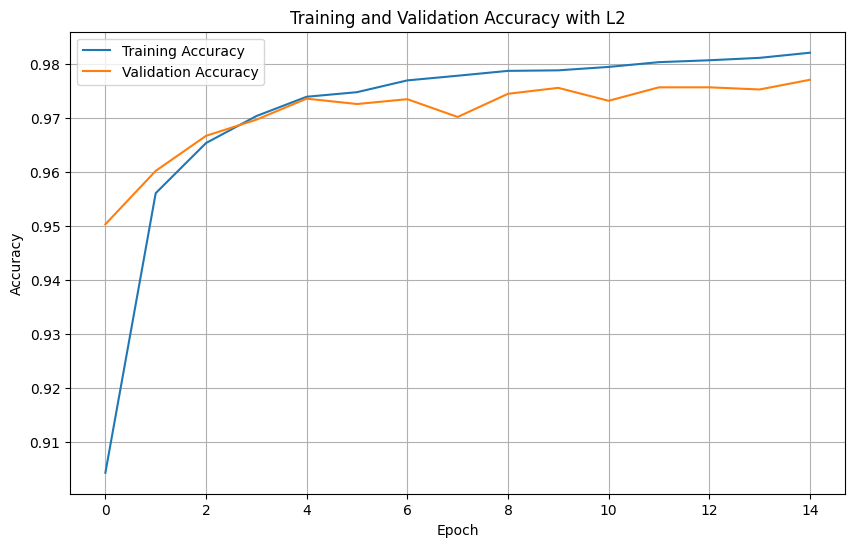

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(l2_history.history['accuracy'], label='Training Accuracy')
plt.plot(l2_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy with L2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

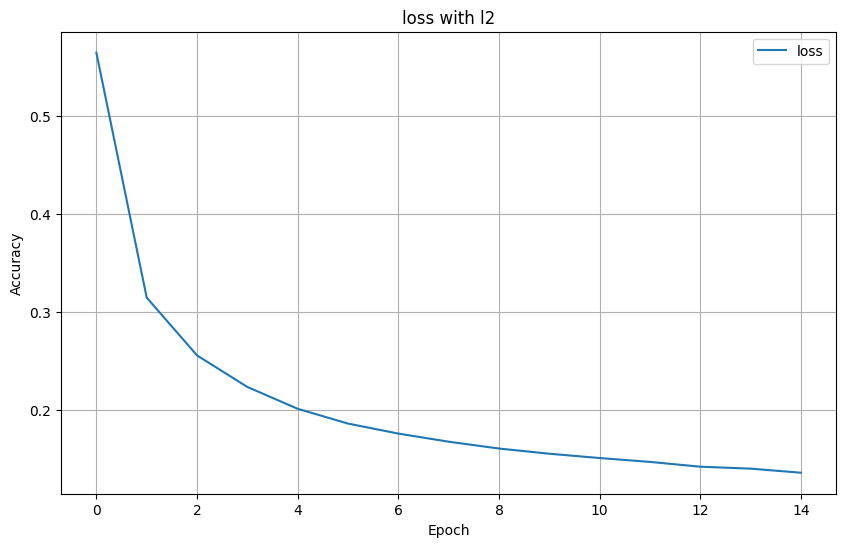

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(l2_history.history['loss'], label='loss')
plt.title('loss with l2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# epochs: How many times the model will see the entire training dataset.
# batch_size: How many images to process before updating the model's weights.
epochs = 15
batch_size = 128

# A Sequential model is a simple stack of layers, one after the other.
model = models.Sequential()

# Layer 1: Input Layer with Dropout
model.add(layers.Dense(128, activation='relu', kernel_initializer=initializers.he_normal(), input_shape=(784,)))
model.add(layers.Dropout(0.2))

# Layer 2: Second Hidden Layer with Dropout
model.add(layers.Dense(64, activation='relu', kernel_initializer=initializers.he_normal()))
model.add(layers.Dropout(0.2))

# Layer 3: Output Layer
model.add(layers.Dense(10, activation='softmax', kernel_initializer=initializers.he_normal()))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("\nModel Summary:")
print(model.summary())

dropout_history = model.fit(
  x_train, y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_data=(x_test, y_test),
  verbose=1  # Set to 0 to hide the progress bar
)


Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7555 - loss: 0.7777 - val_accuracy: 0.9482 - val_loss: 0.1739
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9325 - loss: 0.2187 - val_accuracy: 0.9607 - val_loss: 0.1279
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9537 - loss: 0.1536 - val_accuracy: 0.9689 - val_loss: 0.1005
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9613 - loss: 0.1301 - val_accuracy: 0.9732 - val_loss: 0.0873
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9673 - loss: 0.1074 - val_accuracy: 0.9752 - val_loss: 0.0813
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9699 - loss: 0.0967 - val_accuracy: 0.9761 - val_loss: 0.0767
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9727 - loss: 0.0861 - val_accuracy: 0.9769 - val_loss: 0.0734
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9762 - loss: 0.0756 - val_accurac

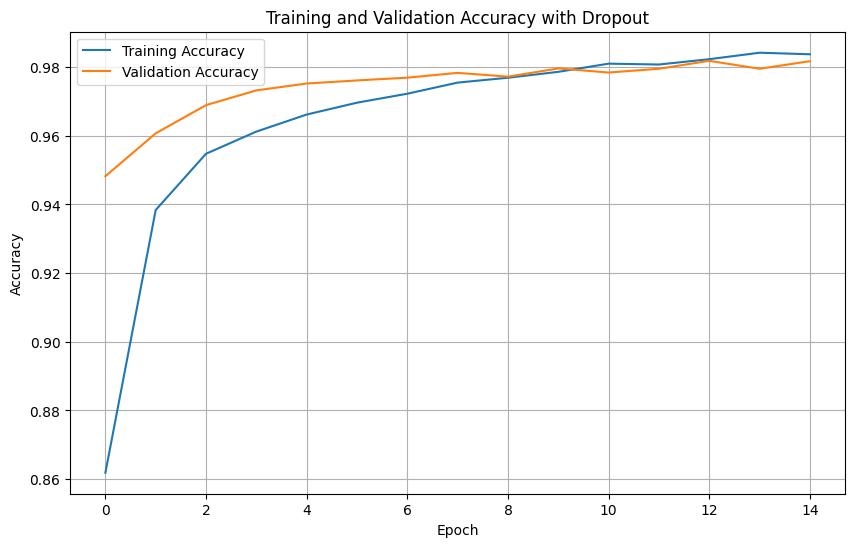

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(dropout_history.history['accuracy'], label='Training Accuracy')
plt.plot(dropout_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

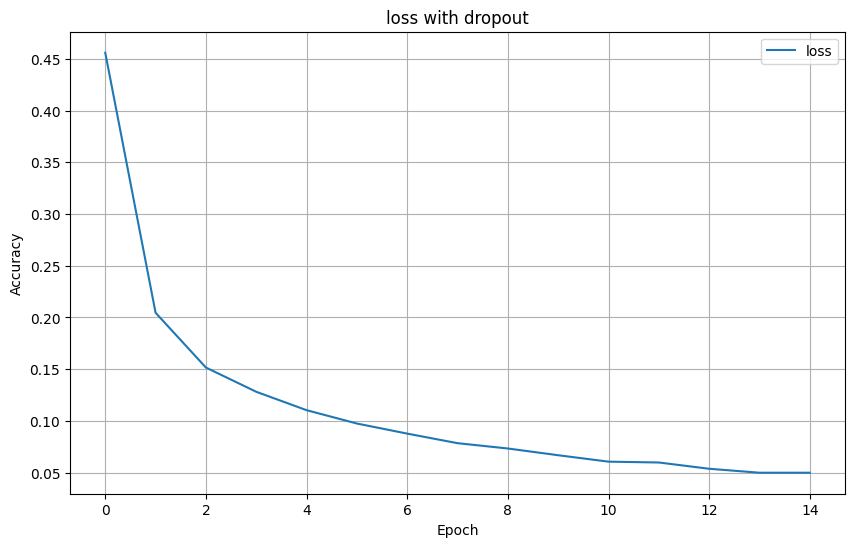

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(dropout_history.history['loss'], label='loss')
plt.title('loss with dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

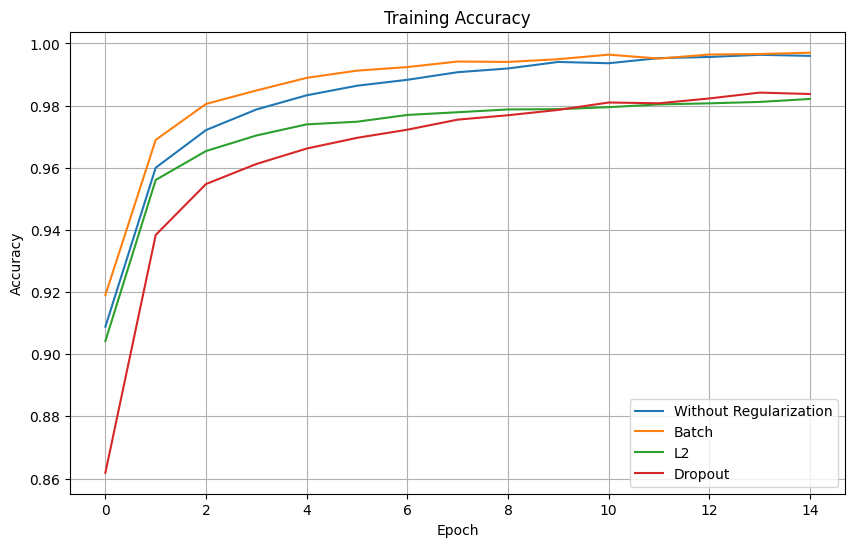

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Without Regularization')
plt.plot(batch_history.history['accuracy'], label='Batch')
plt.plot(l2_history.history['accuracy'], label='L2')
plt.plot(dropout_history.history['accuracy'], label='Dropout')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

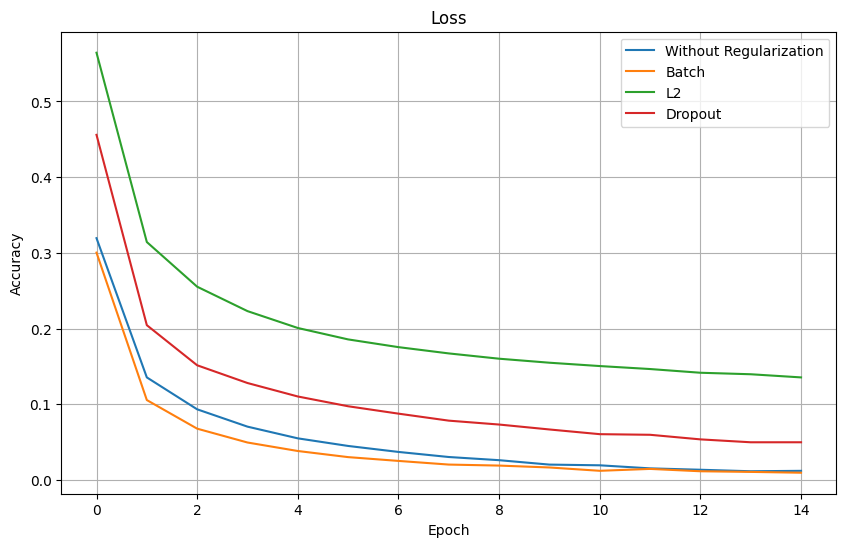

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Without Regularization')
plt.plot(batch_history.history['loss'], label='Batch')
plt.plot(l2_history.history['loss'], label='L2')
plt.plot(dropout_history.history['loss'], label='Dropout')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Extract the last epoch's metrics for each history object

# Baseline Model (without explicit regularization)
baseline_metrics = history.history
baseline_accuracy = baseline_metrics['accuracy'][-1]
baseline_val_accuracy = baseline_metrics['val_accuracy'][-1]
baseline_loss = baseline_metrics['loss'][-1]
baseline_val_loss = baseline_metrics['val_loss'][-1]

# Batch Normalization Model
batch_norm_metrics = batch_history.history
batch_norm_accuracy = batch_norm_metrics['accuracy'][-1]
batch_norm_val_accuracy = batch_norm_metrics['val_accuracy'][-1]
batch_norm_loss = batch_norm_metrics['loss'][-1]
batch_norm_val_loss = batch_norm_metrics['val_loss'][-1]

# L2 Regularization Model
l2_metrics = l2_history.history
l2_accuracy = l2_metrics['accuracy'][-1]
l2_val_accuracy = l2_metrics['val_accuracy'][-1]
l2_loss = l2_metrics['loss'][-1]
l2_val_loss = l2_metrics['val_loss'][-1]

# Dropout Model
dropout_metrics = dropout_history.history
dropout_accuracy = dropout_metrics['accuracy'][-1]
dropout_val_accuracy = dropout_metrics['val_accuracy'][-1]
dropout_loss = dropout_metrics['loss'][-1]
dropout_val_loss = dropout_metrics['val_loss'][-1]

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['Baseline', 'Batch Normalization', 'L2 Regularization', 'Dropout'],
    'Training Accuracy': [baseline_accuracy, batch_norm_accuracy, l2_accuracy, dropout_accuracy],
    'Validation Accuracy': [baseline_val_accuracy, batch_norm_val_accuracy, l2_val_accuracy, dropout_val_accuracy],
    'Training Loss': [baseline_loss, batch_norm_loss, l2_loss, dropout_loss],
    'Validation Loss': [baseline_val_loss, batch_norm_val_loss, l2_val_loss, dropout_val_loss]
}

comparison_df = pd.DataFrame(comparison_data)

print(comparison_df.to_markdown(index=False, numalign="left", stralign="left"))

| Model               | Training Accuracy   | Validation Accuracy   | Training Loss   | Validation Loss   |
|:--------------------|:--------------------|:----------------------|:----------------|:------------------|
| Baseline            | 0.995983            | 0.9769                | 0.012111        | 0.0990052         |
| Batch Normalization | 0.997               | 0.9757                | 0.00961694      | 0.0954816         |
| L2 Regularization   | 0.982117            | 0.9771                | 0.135505        | 0.148814          |
| Dropout             | 0.983717            | 0.9817                | 0.0498406       | 0.0713466         |
